# Exploratory Data Analysis (EDA)

In [1]:
# Automatically reloads modules when you make changes (useful during development)
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))

from src.data import load_data
df_body, df_title, df_subreddits, df_english_pl, df_esports, df_superbowl = load_data()

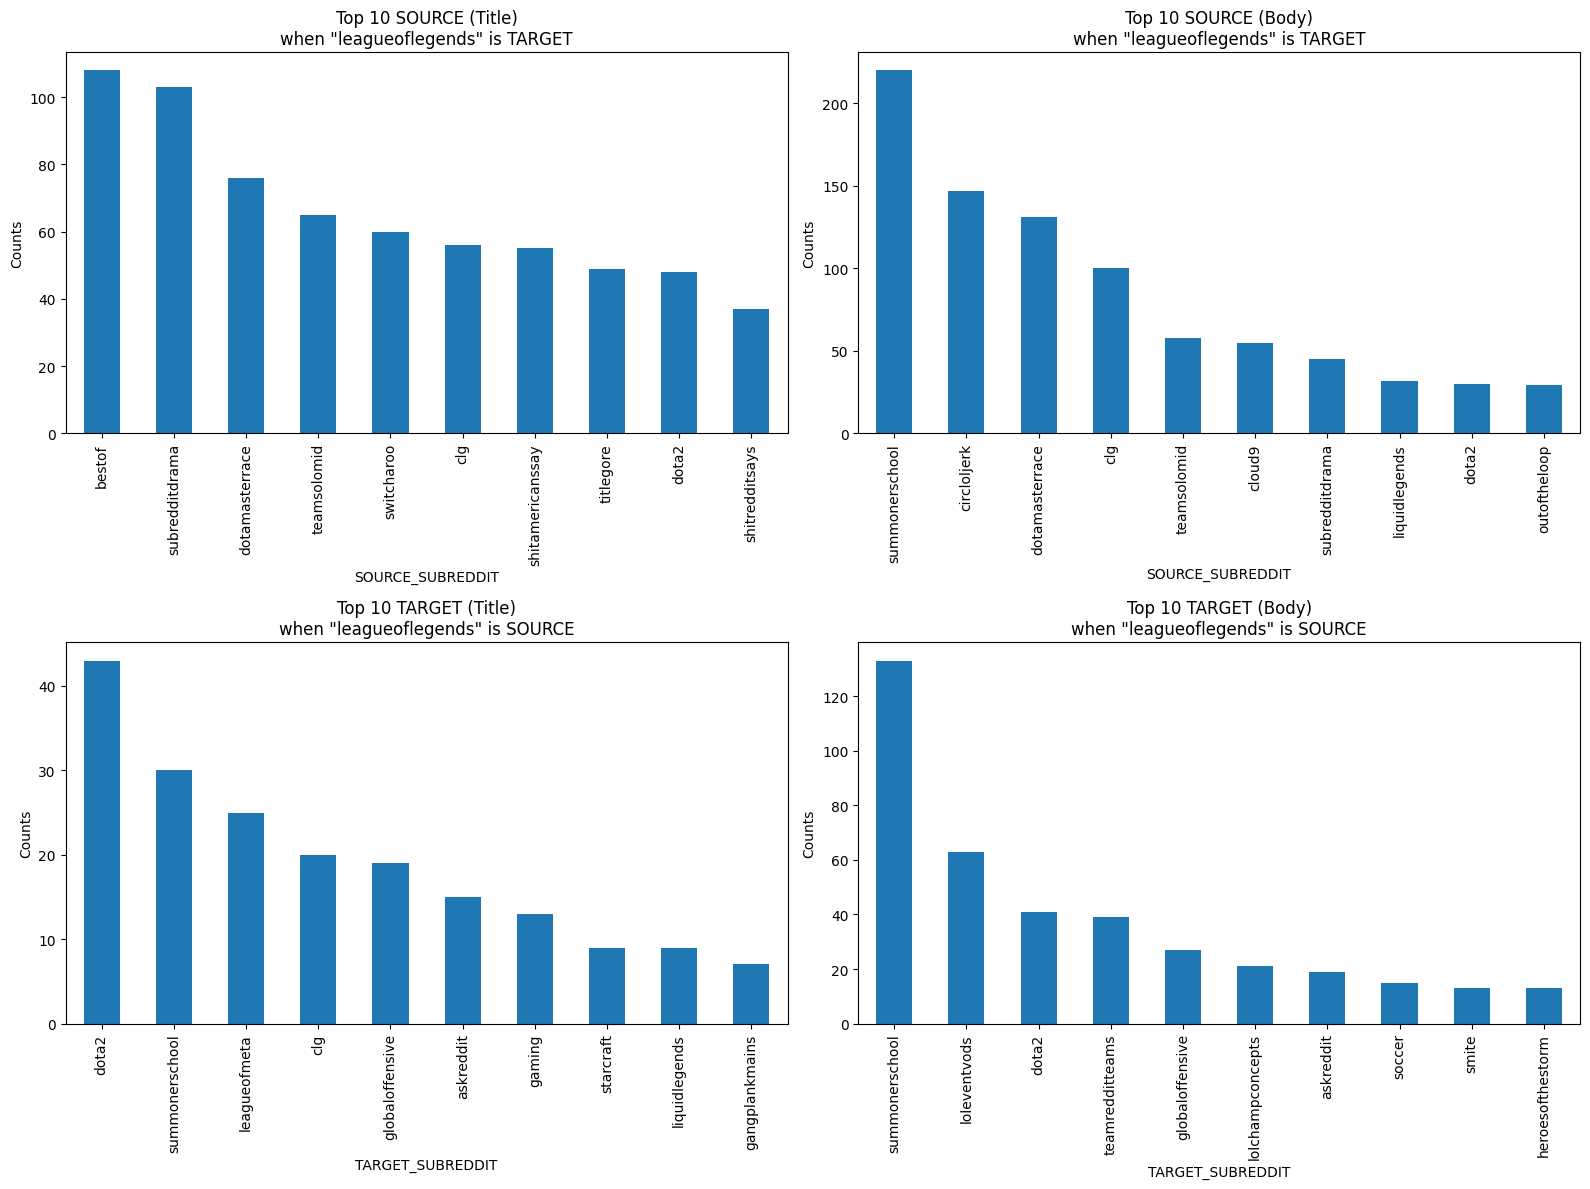

In [3]:
# subreddit = 'dota2'
subreddit = "leagueoflegends"
# subreddit = 'starcraft2'
# subreddit = 'globaloffensive' # globaloffensive or csgo

top_10_source_title = df_title[df_title["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_title = df_title[df_title["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

top_10_source_body = df_body[df_body["TARGET_SUBREDDIT"]==subreddit]["SOURCE_SUBREDDIT"].value_counts().head(10)
top_10_target_body = df_body[df_body["SOURCE_SUBREDDIT"]==subreddit]["TARGET_SUBREDDIT"].value_counts().head(10)

plt.figure(figsize=(16, 12))

# 1. Source Title
plt.subplot(2, 2, 1)
top_10_source_title.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Title)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 2. Source Body
plt.subplot(2, 2, 2)
top_10_source_body.plot(kind='bar')
plt.title(f'Top 10 SOURCE (Body)\nwhen "{subreddit}" is TARGET')
plt.ylabel('Counts')

# 3. Target Title
plt.subplot(2, 2, 3)
top_10_target_title.plot(kind='bar')
plt.title(f'Top 10 TARGET (Title)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

# 4. Target Body
plt.subplot(2, 2, 4)
top_10_target_body.plot(kind='bar')
plt.title(f'Top 10 TARGET (Body)\nwhen "{subreddit}" is SOURCE')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()


In [4]:
dota2_list = []
string = "dota2"
temp = list(df_body[df_body["SOURCE_SUBREDDIT"].str.contains("dota2", case=False, na=False)].SOURCE_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_body[df_body["TARGET_SUBREDDIT"].str.contains("dota2", case=False, na=False)].TARGET_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_title[df_title["SOURCE_SUBREDDIT"].str.contains("dota2", case=False, na=False)].SOURCE_SUBREDDIT.unique())
dota2_list.extend(temp)
temp = list(df_title[df_title["TARGET_SUBREDDIT"].str.contains("dota2", case=False, na=False)].TARGET_SUBREDDIT.unique())
dota2_list.extend(temp)
dota2_list = list(set(dota2_list))
print(f"Total unique subreddits related to 'dota2': {len(dota2_list)}")
# smite_list

Total unique subreddits related to 'dota2': 74


In [5]:
df = df_title
sub = df[df["SOURCE_SUBREDDIT"].isin(dota2_list) | df["TARGET_SUBREDDIT"].isin(dota2_list)]
print(sub["SOURCE_SUBREDDIT"].value_counts().head(10))
print(sub["TARGET_SUBREDDIT"].value_counts().head(10))



SOURCE_SUBREDDIT
dota2              653
dota2circlejerk    195
subredditdrama      91
dotamasterrace      79
bestof              75
learndota2          61
shitredditsays      48
leagueoflegends     45
titlegore           34
circlebroke2        33
Name: count, dtype: int64
TARGET_SUBREDDIT
dota2              1480
leagueoflegends      52
globaloffensive      44
learndota2           36
dota2modding         30
askreddit            29
dotaconcepts         28
truedota2            27
steam                23
dota2circlejerk      18
Name: count, dtype: int64


In [6]:
temp_list = []
string = "offensive"
temp = list(df_body[df_body["SOURCE_SUBREDDIT"].str.contains(string, case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_body[df_body["TARGET_SUBREDDIT"].str.contains(string, case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_title[df_title["SOURCE_SUBREDDIT"].str.contains(string, case=False, na=False)].SOURCE_SUBREDDIT.unique())
temp_list.extend(temp)
temp = list(df_title[df_title["TARGET_SUBREDDIT"].str.contains(string, case=False, na=False)].TARGET_SUBREDDIT.unique())
temp_list.extend(temp)
temp_list = list(set(temp_list))
print(f"Total unique subreddits related to {string}: {len(temp_list)}")

Total unique subreddits related to offensive: 17


In [7]:
temp_list

['kyleoffensive',
 'classicoffensive',
 'offensiveflags',
 'globaloffensivetrade',
 'globaloffensivemarket',
 'globaloffensivegamble',
 'globaloffensivetil',
 'globaloffensivelinux',
 'offensivespeech',
 'globaloffensive_vods',
 'isitfunnyoroffensive',
 'offensive_wallpapers',
 'globaloffensive',
 'offensive',
 'ripglobaloffensive',
 'offensivejokes',
 'globaloffensivetest']

In [9]:
dota2_subreddits = [
    'dota2', 'dota2circlejerk','dota2trade', 'learndota2', 'dota2betting', 
    'dotamasterrace', 'truedota2', 'dota2modding', 'dota2loungebets', 'redditdota2league',
]
lol_subreddits = [
    "leagueoflegends", "leagueoflegendsmeta", "summonerschool",  "clg", 
    "circloljerk", 'leagueconnect', 'lolesports'
    ]

starcraft2_subreddits = [
     'starcraft2',  'starcraft', 'starcraftcirclejerk', 'unexpectedstarcraft',
     'imaginarystarcraft', 'starcraft_strategy', 'ukstarcraft', 'starcraftbirthdays',
     'starcraftdeutschland', 'huskystarcraft', 'starcraftfeedback','psystarcraft',]

globaloffensive_subreddits = [
    'globaloffensive', 'globaloffensivetrade', 'globaloffensivemarket',
    'csgo', 'csgojerk', 'csgobetting',
]

games = ["gaming", "dota2", "leagueoflegends", "starcraft2", "globaloffensive"]


### Sentiment andLIWC attributes

array([[3.86898799e+02, 9.19064668e+01, 9.66676992e+01, 1.28269846e+02,
        9.07776755e+01, 8.20046802e+01, 8.49942710e+01, 5.06074921e+01,
        4.19138717e+01, 5.78120296e+01, 5.02685011e+01, 1.77944875e+01,
        5.31337161e+01, 3.69099841e+01, 3.56245200e+01, 4.27786717e+01,
        4.22155993e+01, 3.56422143e+01, 4.69588883e+01, 3.08318731e+01],
       [4.64847740e+02, 1.09510417e+02, 1.13207082e+02, 1.52891579e+02,
        1.04337768e+02, 1.07038875e+02, 1.11633890e+02, 5.45381201e+01,
        5.02972598e+01, 6.06999432e+01, 6.21337576e+01, 5.59909593e+01,
        5.83601598e+01, 4.17998221e+01, 3.70507713e+01, 5.32491085e+01,
        5.83847813e+01, 4.52745663e+01, 5.38640191e+01, 3.54589350e+01],
       [3.31883449e+02, 9.94497502e+01, 8.21756342e+01, 1.11786742e+02,
        8.06312550e+01, 6.75792218e+01, 7.65610172e+01, 3.55922594e+01,
        5.55295587e+01, 4.89648704e+01, 4.19196755e+01, 1.44342460e+01,
        4.65525241e+01, 3.05632177e+01, 2.55303167e+01, 3.9400

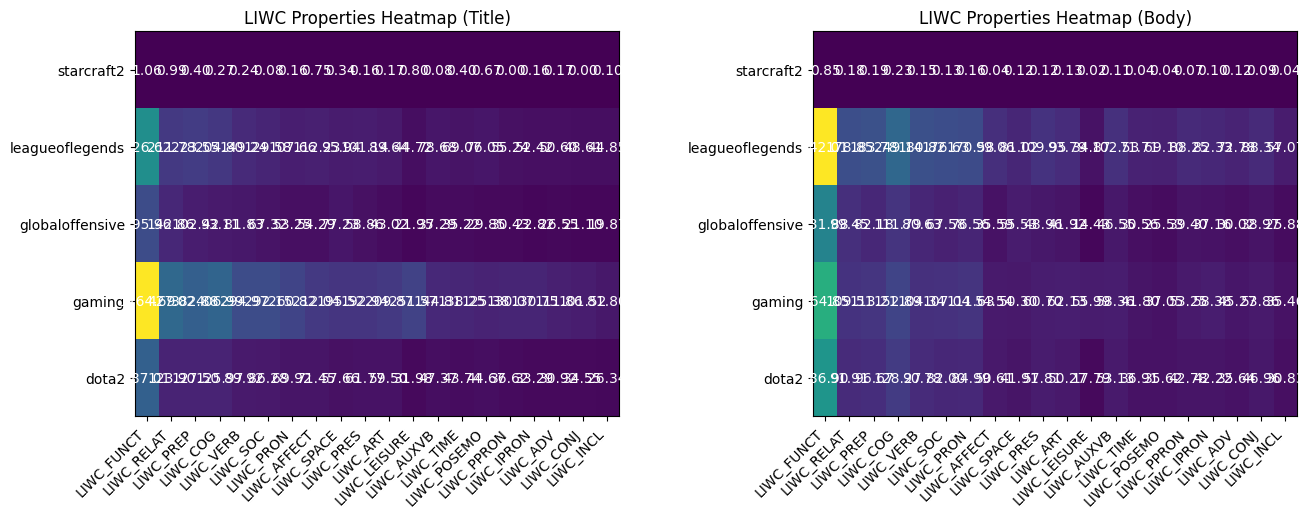

In [11]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list
from src.consts import PROPERTIES
from week1_Yuri import get_dataframe_features

subreddits_list = games
features = list(PROPERTIES.keys())[18:]
df_features_sentiment, df_features_liwc = get_dataframe_features(
    df_title, df_body, features, subreddits_list
)

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
properties_list = df_features_liwc.sort_values(
    by=['Sum_Title', 'Sum_Body'], ascending=False
).head(20)["Feature"].tolist()

plot_liwc_heatmaps_for_features_list(
    ax[0], df_title, games, properties_list, title='LIWC Properties Heatmap (Title)')

plot_liwc_heatmaps_for_features_list(
    ax[1], df_body, games, properties_list, title='LIWC Properties Heatmap (Body)')

array([[3.03487506e+00, 7.21081935e-01, 6.45697116e-01, 1.12742160e+00,
        8.14225172e-01, 7.47147154e-01, 7.28461381e-01, 4.41028965e-01,
        2.55921607e-01, 4.97013168e-01],
       [2.17716072e+01, 5.77688229e+00, 5.46166349e+00, 7.14860833e+00,
        5.12007031e+00, 4.51573736e+00, 5.26405045e+00, 2.43402555e+00,
        2.55801377e+00, 2.82924659e+00],
       [7.13143606e-01, 1.98088625e-01, 1.91001119e-01, 2.38908292e-01,
        1.41759211e-01, 1.41893367e-01, 1.46809372e-01, 1.27343174e-01,
        1.13452391e-01, 1.02258361e-01],
       [3.31883449e+02, 9.94497502e+01, 8.21756342e+01, 1.11786742e+02,
        8.06312550e+01, 6.75792218e+01, 7.65610172e+01, 3.55922594e+01,
        5.55295587e+01, 4.89648704e+01],
       [1.08346782e+02, 3.16713586e+01, 2.58141843e+01, 3.44273303e+01,
        2.36611640e+01, 2.35724074e+01, 2.65356021e+01, 1.20398293e+01,
        1.70325108e+01, 1.39802428e+01]])

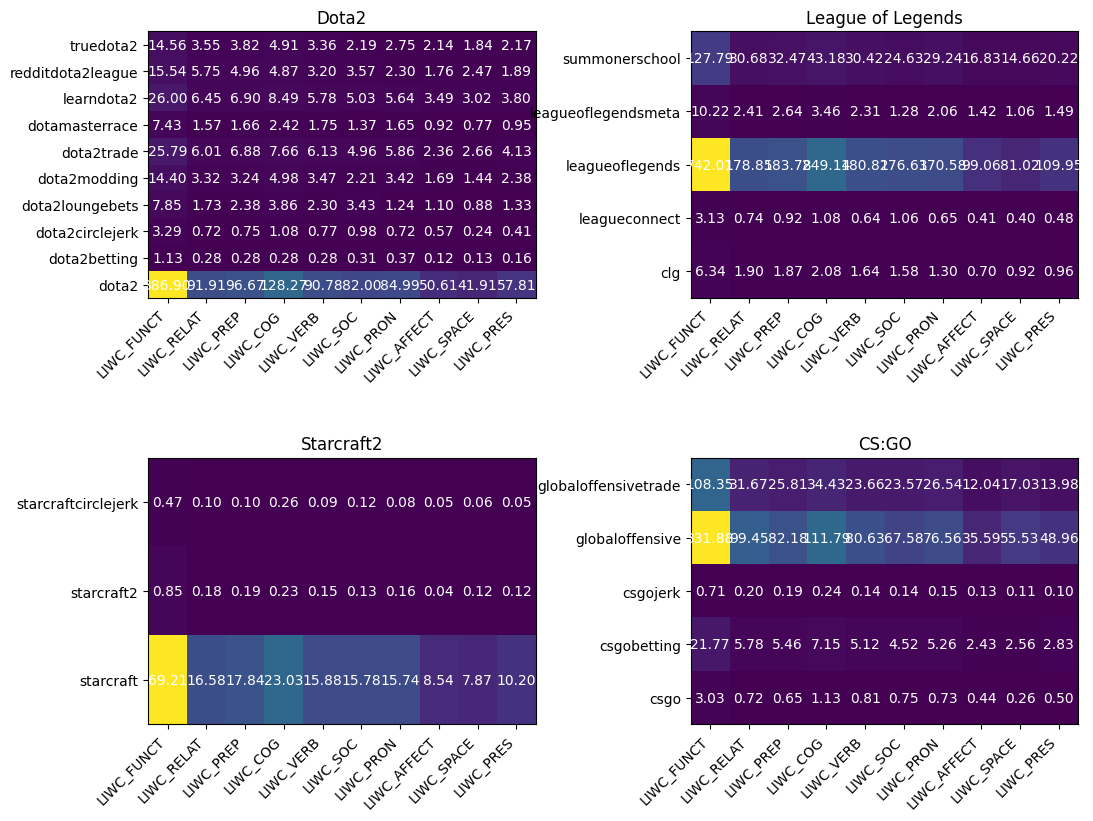

In [12]:
from week1_Yuri import plot_liwc_heatmaps_for_features_list

fig, ax = plt.subplots(2, 2, figsize = (12, 9))
plt.subplots_adjust(hspace=0.6, wspace=0.4)
properties_list = df_features_liwc.sort_values(by=['Sum_Title', 'Sum_Body'], ascending=False).head(10)["Feature"].tolist()
plot_liwc_heatmaps_for_features_list(
    ax[0][0], df_body, dota2_subreddits, properties_list, title='Dota2')
plot_liwc_heatmaps_for_features_list(
    ax[0][1], df_body, lol_subreddits, properties_list, title='League of Legends')
plot_liwc_heatmaps_for_features_list(
    ax[1][0], df_body, starcraft2_subreddits, properties_list, title='Starcraft2')
plot_liwc_heatmaps_for_features_list(
    ax[1][1], df_body, globaloffensive_subreddits, properties_list, title='CS:GO')

### Spikes and trends of selected features over time for a given subreddits

Title
3338


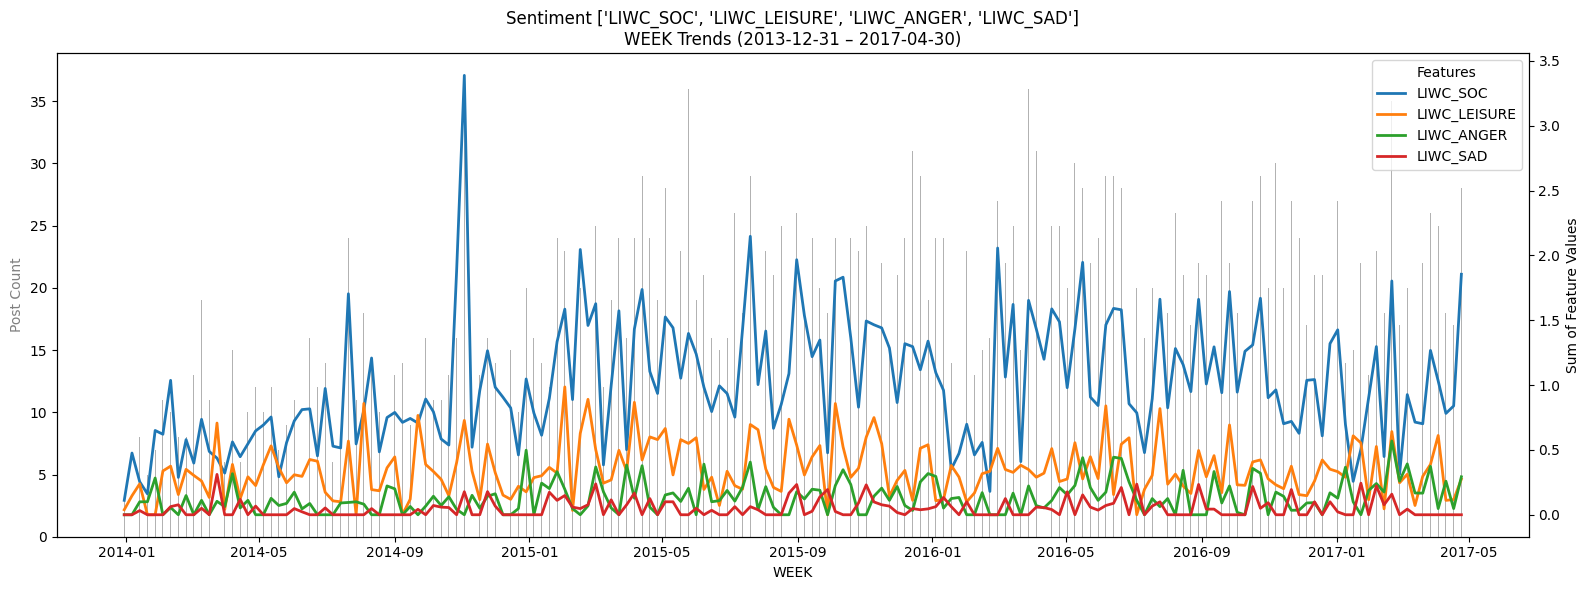

Body
3609


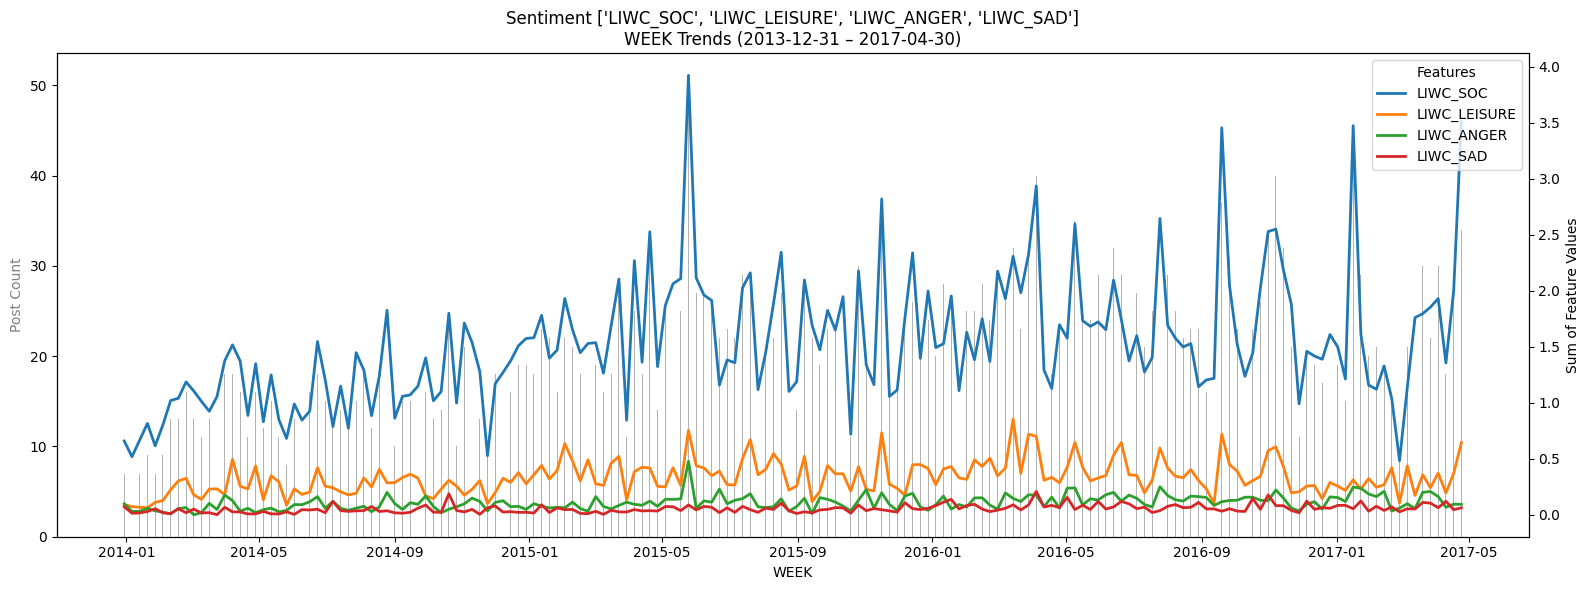

In [13]:
from week1_Yuri import plot_subreddits_features_trend 
subreddits_list = lol_subreddits
start_time = "2013-12-31"
end_time = "2017-04-30"
features_list = [
    "LIWC_SOC",
    "LIWC_LEISURE",
    "LIWC_ANGER",
    "LIWC_SAD",
]
period = "W"  # "D" for daily, "W" for weekly, "M" for monthly, "Q" for quarterly, "Y" for yearly
print("Title")
plot_subreddits_features_trend(df_title, subreddits_list, start_time, end_time, features_list, period)
print("Body")
plot_subreddits_features_trend(df_body, subreddits_list, start_time, end_time, features_list, period)